# Ramsey (T2*)

In [8]:
from pathlib import Path

import numpy as np

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.experiments.cal10_ramsey import Ramsey

## Run parameters

In [9]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = Path("data")

QUBITS = ["q1"]
DELAYS = np.arange(start=0, stop=10, step=0.1, dtype=float) * 1e-6
FREQUENCY_DETUNING = 50e3
REPETITIONS = 100
RESET_TYPE = "thermal"  # "thermal" or "active" (ConditionalReset)

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None to skip persistence

## Hardware and experiment

In [10]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = Ramsey(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [11]:
dataset = experiment.run_measurement(
    delays=DELAYS,
    frequency_detuning=FREQUENCY_DETUNING,
    repetitions=REPETITIONS,
    reset_type=RESET_TYPE,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 8kB
Dimensions:           (acq_index_S21_q1: 200)
Coordinates:
    delay_q1          (acq_index_S21_q1) float64 2kB 0.0 0.0 ... 9.9e-06 9.9e-06
    sign_q1           (acq_index_S21_q1) int64 2kB 1 -1 1 -1 1 ... -1 1 -1 1 -1
  * acq_index_S21_q1  (acq_index_S21_q1) int64 2kB 0 1 2 3 4 ... 196 197 198 199
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 3kB (-7.43300077650282e-0...
Attributes:
    tuid:     20260825-045254-071-fef437

## Optional: Simulated data

In [12]:
# dataset = experiment.simulated_data(
#     delays=DELAYS,
#     frequency_detuning=FREQUENCY_DETUNING,
#     repetitions=REPETITIONS,
#     frequency_error=50e3,
#     t2_star=15e-6,
#     noise=0.01,
#     seed=42,
# )

## Analysis

In [13]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(f"{qubit}: T2* = {result.t2_star / 1e-6:.3f} us | "
              f"frequency error = {result.frequency_error / 1e3:+.3f} kHz")
    else:
        print(f"{qubit}: Ramsey fit failed on one or both detuning-sign branches")

q1: T2* = 37.132 us | frequency error = -278.396 kHz


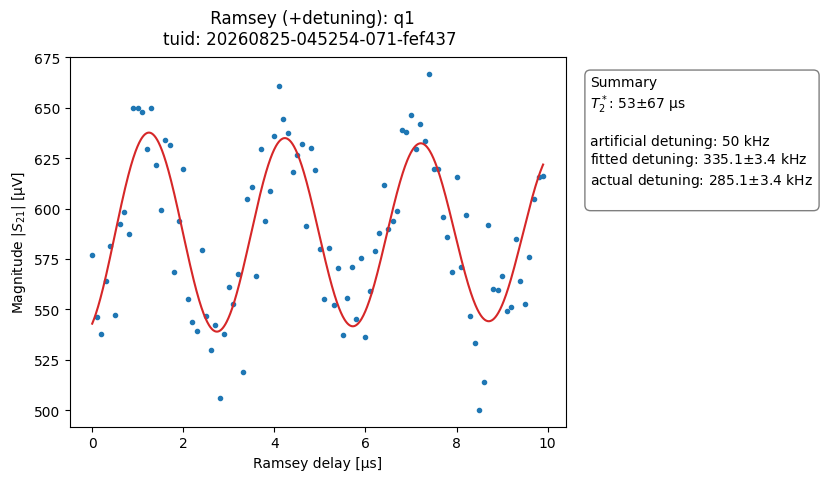

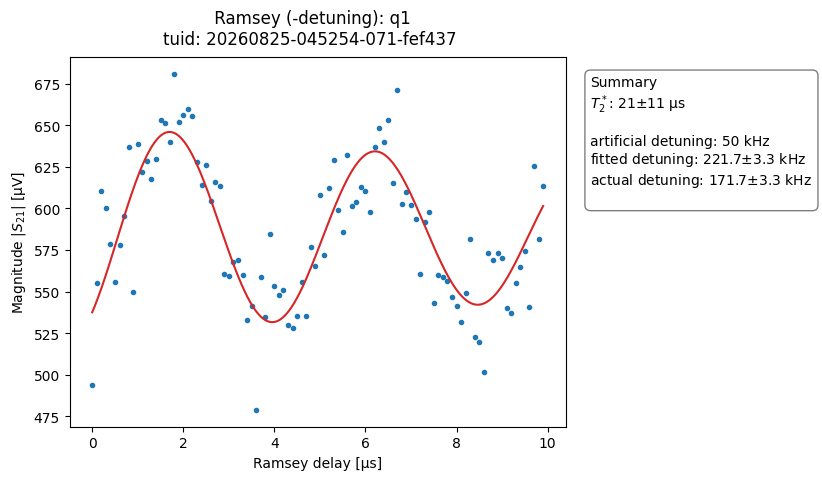

In [14]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [15]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()